Looking for NetCDF files in: /Users/edward/Desktop/Curriculum/EART60702/project_2
Found 6 file(s):
 - 003_2006_2080_352_360.nc
 - 004_2006_2080_352_360.nc
 - 005_2006_2080_352_360.nc
 - 006_2006_2080_352_360.nc
 - 007_2006_2080_352_360.nc
 - 008_2006_2080_352_360.nc

Loading data...

Loading member 003: 003_2006_2080_352_360.nc
Loaded 27,374 rows for member 003

Loading member 004: 004_2006_2080_352_360.nc
Loaded 27,374 rows for member 004

Loading member 005: 005_2006_2080_352_360.nc
Loaded 27,374 rows for member 005

Loading member 006: 006_2006_2080_352_360.nc
Loaded 27,374 rows for member 006

Loading member 007: 007_2006_2080_352_360.nc
Loaded 27,374 rows for member 007

Loading member 008: 008_2006_2080_352_360.nc
Loaded 27,374 rows for member 008

Loaded 164,244 rows
11 features: ['TREFHT', 'FSNS', 'QBOT', 'FLNS', 'UBOT', 'VBOT', 'PRECT', 'PRSN', 'sin_doy', 'cos_doy', 'year_norm']

Train: 96,354 samples (2006-2049)
Test:  67,890 samples (2050-2080)

Training Ridge Regression...


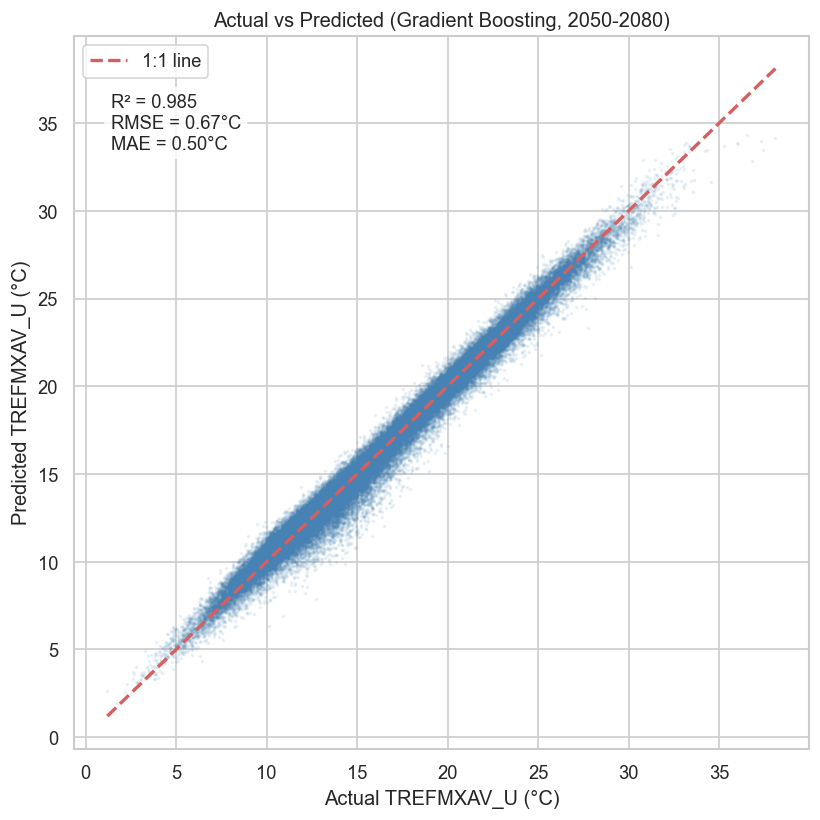

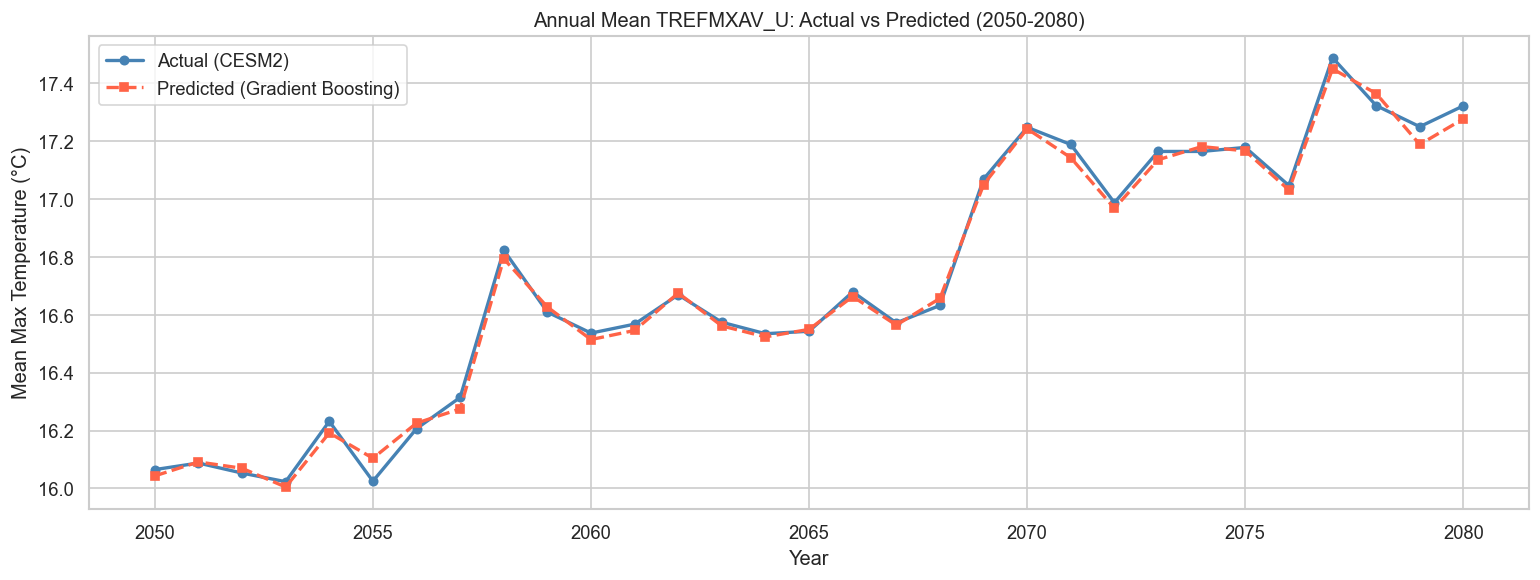

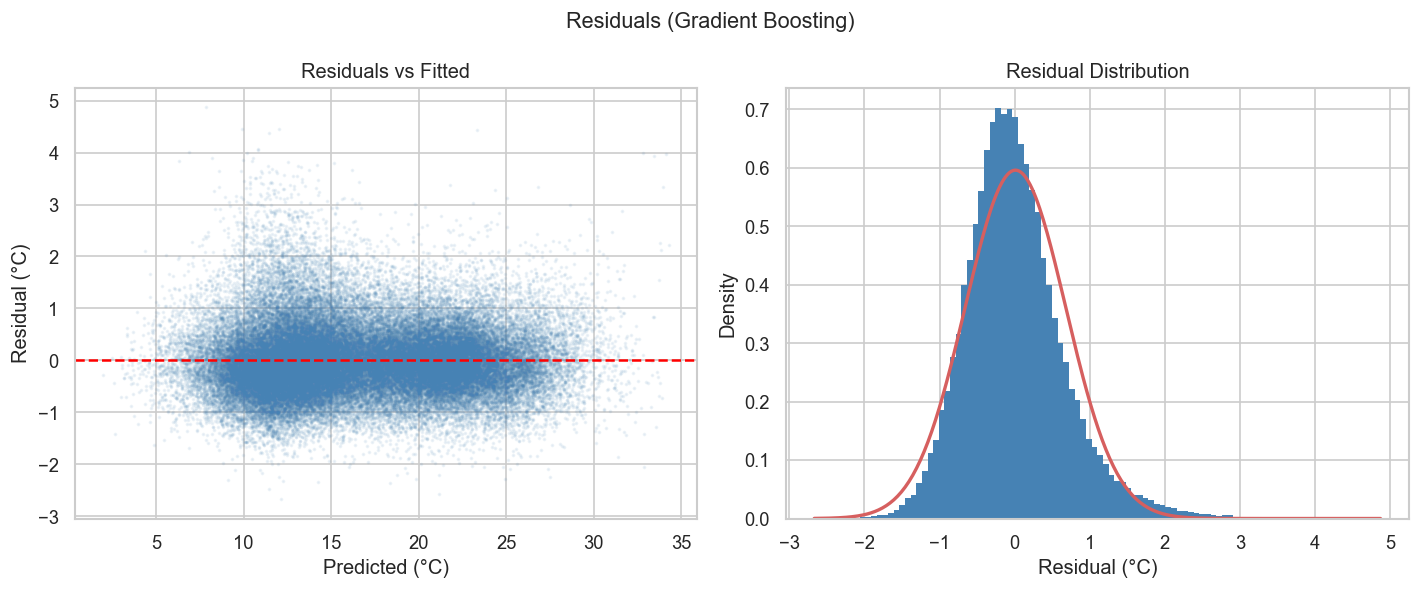

Residual mean: 0.0097°C
Residual std:  0.6692°C


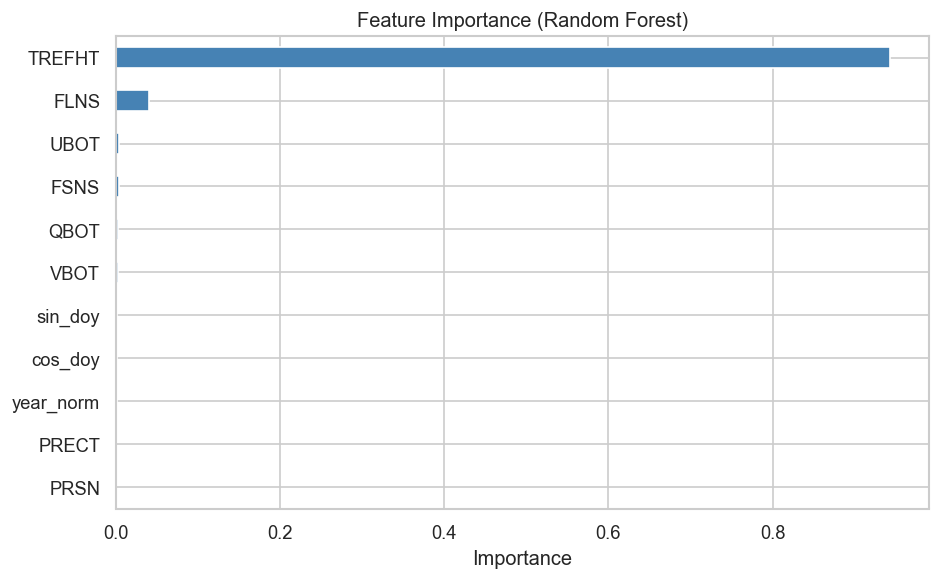


Saved predictions to predictions_2050_2080.csv


In [3]:
# %%
# 02_ml_model.py
# Supervised learning model for predicting TREFMXAV_U at Manchester
#
# Train on 2006-2049, predict 2050-2080
# Features: TREFHT, FSNS, QBOT, FLNS, UBOT, VBOT, PRECT, PRSN
#           plus cyclical day-of-year and normalised year
# Target: TREFMXAV_U in Celsius

import os
import glob
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

# %%
# Find NetCDF files

DATA_DIR = "."
NC_FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc*")))

print(f"Looking for NetCDF files in: {os.path.abspath(DATA_DIR)}")
print(f"Found {len(NC_FILES)} file(s):")
for f in NC_FILES:
    print(" -", os.path.basename(f))

if len(NC_FILES) == 0:
    raise FileNotFoundError(
        "No NetCDF files found in the current folder."
    )

MEMBER_IDS = [os.path.basename(f).split("_")[0] for f in NC_FILES]

MAN_LAT = 53.48
MAN_LON = 357.76

ALL_VARS = ["TREFMXAV_U", "TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
FEATURE_VARS = ["TREFHT", "FSNS", "QBOT", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]

# %%
# Helper to open dataset with available engine

def open_nc_file(fpath):
    engines = ["netcdf4", "h5netcdf"]
    last_error = None

    for engine in engines:
        try:
            return xr.open_dataset(fpath, engine=engine, decode_times=True)
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not open {os.path.basename(fpath)} with netcdf4 or h5netcdf. "
        f"Last error: {last_error}"
    )

# %%
# Load data

print("\nLoading data...")
frames = []

for mid, fpath in zip(MEMBER_IDS, NC_FILES):
    try:
        print(f"\nLoading member {mid}: {os.path.basename(fpath)}")

        ds = open_nc_file(fpath)

        # Check required variables exist
        required_coords = ["lat", "lon", "time"]
        for c in required_coords:
            if c not in ds.coords and c not in ds.variables:
                raise ValueError(f"Missing required coordinate/variable: {c}")

        for v in ALL_VARS:
            if v not in ds.variables:
                raise ValueError(f"Missing required variable: {v}")

        sel = ds[ALL_VARS].sel(lat=MAN_LAT, lon=MAN_LON, method="nearest")
        df = sel.to_dataframe().reset_index()

        if df.empty:
            print(f"Skipping {mid}: dataframe is empty")
            ds.close()
            continue

        df["year"] = [t.year for t in df["time"]]
        df["month"] = [t.month for t in df["time"]]
        df["doy"] = [t.timetuple().tm_yday for t in df["time"]]
        df["member"] = mid
        df["TREFMXAV_U_C"] = df["TREFMXAV_U"] - 273.15

        frames.append(df)
        print(f"Loaded {len(df):,} rows for member {mid}")

        ds.close()

    except Exception as e:
        print(f"Error loading {os.path.basename(fpath)}: {e}")
        continue

if len(frames) == 0:
    raise ValueError(
        "No valid datasets were loaded. Check that the files contain "
        "lat, lon, time, and all required climate variables."
    )

data = pd.concat(frames, ignore_index=True)
print(f"\nLoaded {len(data):,} rows")

# %%
# Feature engineering
#
# sin/cos encoding of day-of-year so Dec 31 and Jan 1 are close together.
# year_norm goes from 0 (2006) to 1 (2080) to give the model a trend signal.

data["sin_doy"] = np.sin(2 * np.pi * data["doy"] / 365.25)
data["cos_doy"] = np.cos(2 * np.pi * data["doy"] / 365.25)

YEAR_MIN = data["year"].min()
YEAR_MAX = data["year"].max()
data["year_norm"] = (data["year"] - YEAR_MIN) / (YEAR_MAX - YEAR_MIN)

FEATURE_COLS = FEATURE_VARS + ["sin_doy", "cos_doy", "year_norm"]

print(f"{len(FEATURE_COLS)} features: {FEATURE_COLS}")

# %%
# Train/test split - temporal, not random

train = data[data["year"] <= 2049].copy()
test = data[data["year"] >= 2050].copy()

X_train = train[FEATURE_COLS].values
y_train = train["TREFMXAV_U_C"].values

X_test = test[FEATURE_COLS].values
y_test = test["TREFMXAV_U_C"].values

print(f"\nTrain: {len(X_train):,} samples ({train['year'].min()}-{train['year'].max()})")
print(f"Test:  {len(X_test):,} samples ({test['year'].min()}-{test['year'].max()})")

# Ridge needs scaled features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# %%
# Train three models and compare

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    Xtr = X_train_s if name == "Ridge Regression" else X_train
    Xte = X_test_s if name == "Ridge Regression" else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"  MAE = {mae:.3f}°C   RMSE = {rmse:.3f}°C   R² = {r2:.4f}")

best_name = max(results, key=lambda k: results[k]["R2"])
best_preds = results[best_name]["preds"]

print(f"\nBest: {best_name} (R²={results[best_name]['R2']:.4f})")

# %%
# Metrics table

metrics_df = pd.DataFrame(
    {
        k: {
            "MAE (°C)": v["MAE"],
            "RMSE (°C)": v["RMSE"],
            "R²": v["R2"]
        }
        for k, v in results.items()
    }
).T.round(4)

print("\nModel performance on 2050-2080:")
print(metrics_df.to_string())
metrics_df.to_csv("model_metrics.csv")

# %%
# Scatter: actual vs predicted (best model)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, best_preds, s=1.5, alpha=0.08, color="steelblue", rasterized=True)

lims = [
    min(y_test.min(), best_preds.min()),
    max(y_test.max(), best_preds.max())
]
ax.plot(lims, lims, "r--", lw=2, label="1:1 line")

ax.set_xlabel("Actual TREFMXAV_U (°C)")
ax.set_ylabel("Predicted TREFMXAV_U (°C)")
ax.set_title(f"Actual vs Predicted ({best_name}, 2050-2080)")
ax.legend()

ax.text(
    0.05, 0.92,
    f"R² = {results[best_name]['R2']:.3f}\n"
    f"RMSE = {results[best_name]['RMSE']:.2f}°C\n"
    f"MAE = {results[best_name]['MAE']:.2f}°C",
    transform=ax.transAxes,
    fontsize=11,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig("ml_01_scatter.png", dpi=150)
plt.show()

# %%
# Annual means: actual vs predicted over the test period

test_df = test.copy()
test_df["predicted_C"] = best_preds

ann_obs = test_df.groupby("year")["TREFMXAV_U_C"].mean()
ann_pred = test_df.groupby("year")["predicted_C"].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    ann_obs.index, ann_obs.values,
    "o-",
    color="steelblue",
    lw=2,
    ms=5,
    label="Actual (CESM2)"
)
ax.plot(
    ann_pred.index, ann_pred.values,
    "s--",
    color="tomato",
    lw=2,
    ms=5,
    label=f"Predicted ({best_name})"
)

ax.set_title("Annual Mean TREFMXAV_U: Actual vs Predicted (2050-2080)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Max Temperature (°C)")
ax.legend()

plt.tight_layout()
plt.savefig("ml_02_annual_comparison.png", dpi=150)
plt.show()

# %%
# Residual analysis

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(best_preds, residuals, s=1.5, alpha=0.08, color="steelblue", rasterized=True)
axes[0].axhline(0, color="red", ls="--", lw=1.5)
axes[0].set_xlabel("Predicted (°C)")
axes[0].set_ylabel("Residual (°C)")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=100, color="steelblue", density=True, edgecolor="none")
xs = np.linspace(residuals.min(), residuals.max(), 300)
axes[1].plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()), "r-", lw=2)
axes[1].set_xlabel("Residual (°C)")
axes[1].set_ylabel("Density")
axes[1].set_title("Residual Distribution")

plt.suptitle(f"Residuals ({best_name})", fontsize=13)
plt.tight_layout()
plt.savefig("ml_03_residuals.png", dpi=150)
plt.show()

print(f"Residual mean: {residuals.mean():.4f}°C")
print(f"Residual std:  {residuals.std():.4f}°C")

# %%
# Feature importance from Random Forest

rf_model = results["Random Forest"]["model"]
fi = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("ml_04_feature_importance.png", dpi=150)
plt.show()

# %%
# Save predictions to CSV

output = test_df[["time", "member", "year", "month", "TREFMXAV_U_C", "predicted_C"]].copy()
output.to_csv("predictions_2050_2080.csv", index=False)
print("\nSaved predictions to predictions_2050_2080.csv")


Training QBOT Ridge Regression...

Training QBOT Random Forest...

Training QBOT Gradient Boosting...

Readable QBOT skill summary:
       best_model  MAE (kg/kg)  MAE (g/kg)  RMSE (kg/kg)  RMSE (g/kg)     R²  Mean QBOT (kg/kg)  Mean QBOT (g/kg)  MAE as % of mean  RMSE as % of mean
Gradient Boosting       0.0004      0.3907        0.0005        0.536 0.9425             0.0069            6.8936            5.6672             7.7746

Seasonal QBOT skill:
season  samples  MAE (kg/kg)  MAE (g/kg)  RMSE (kg/kg)  RMSE (g/kg)     R²
   DJF    16740       0.0003      0.2559        0.0003       0.3306 0.9249
   MAM    17112       0.0004      0.3581        0.0005       0.4859 0.8947
   JJA    17112       0.0005      0.5482        0.0007       0.7203 0.8358
   SON    16926       0.0004      0.3977        0.0005       0.5299 0.9168


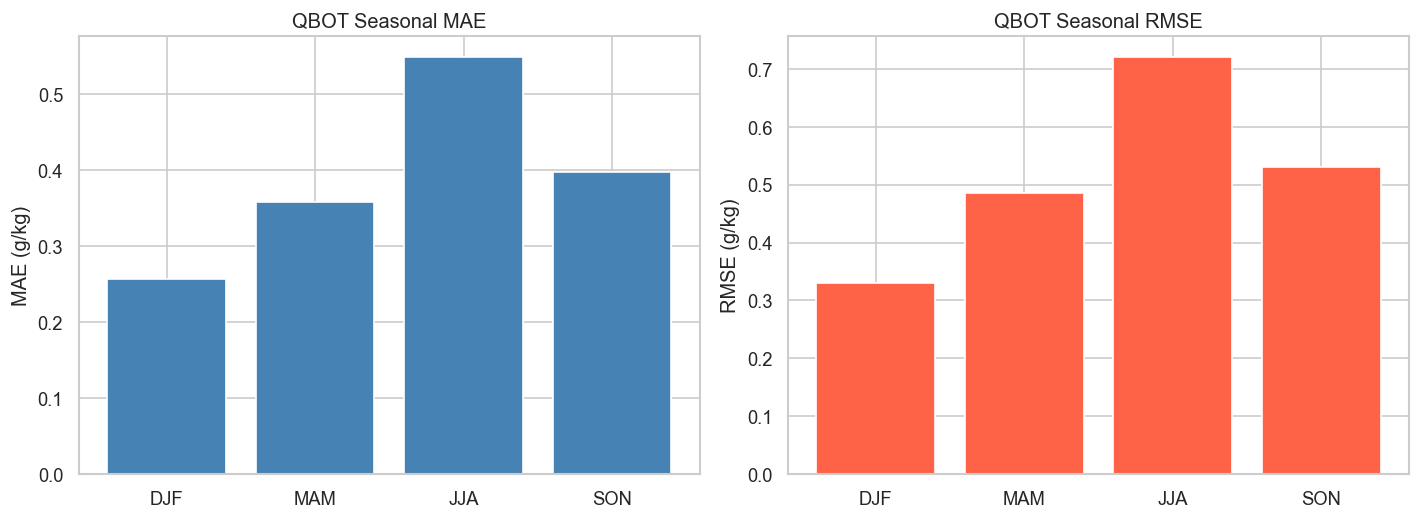


Training QBOT ablation Ridge Regression...

Training QBOT ablation Random Forest...

Training QBOT ablation Gradient Boosting...

Best ablation QBOT model: Gradient Boosting (R²=0.9390)

QBOT ablation model performance on 2050-2080:
                   MAE (kg/kg)  RMSE (kg/kg)        R²
Ridge Regression      0.000531      0.000705  0.900454
Random Forest         0.000415      0.000565  0.935969
Gradient Boosting     0.000406      0.000552  0.938973

QBOT feature-set comparison:
         feature_set        best_model  n_features  MAE (g/kg)  RMSE (g/kg)     R²
   With TREFMXAV_U_C Gradient Boosting          11      0.3907       0.5360 0.9425
Without TREFMXAV_U_C Gradient Boosting          10      0.4060       0.5519 0.9390


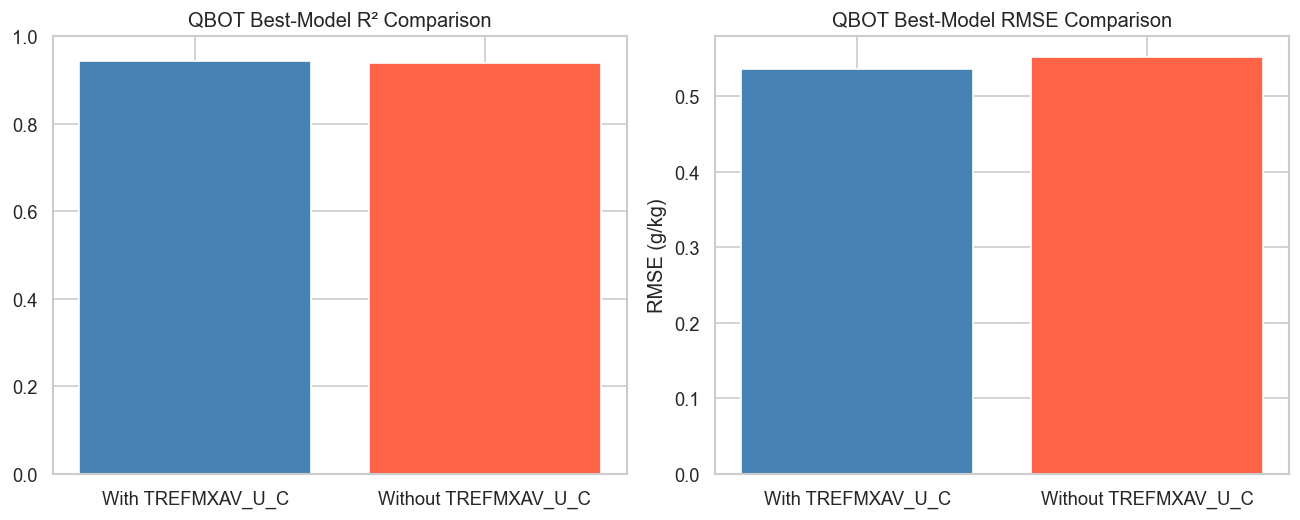


Enhanced QBOT model diagnostics done.


In [4]:
# %%
# 03B_ml_model_qbot_extensions.py
# QBOT-specific diagnostics: readable units, seasonal skill, and ablation without Tmax.

if "QBOT" not in data.columns:
    raise ValueError("Missing QBOT column for QBOT model diagnostics.")

if "sin_doy" not in data.columns:
    data["sin_doy"] = np.sin(2 * np.pi * data["doy"] / 365.25)
if "cos_doy" not in data.columns:
    data["cos_doy"] = np.cos(2 * np.pi * data["doy"] / 365.25)
if "year_norm" not in data.columns:
    data["year_norm"] = (data["year"] - data["year"].min()) / (data["year"].max() - data["year"].min())

QBOT_FEATURE_VARS = ["TREFMXAV_U_C", "TREFHT", "FSNS", "FLNS", "UBOT", "VBOT", "PRECT", "PRSN"]
QBOT_FEATURE_COLS = QBOT_FEATURE_VARS + ["sin_doy", "cos_doy", "year_norm"]

qbot_train = data[data["year"] <= 2049].copy()
qbot_test = data[data["year"] >= 2050].copy()

qbot_X_train = qbot_train[QBOT_FEATURE_COLS].values
qbot_y_train = qbot_train["QBOT"].values
qbot_X_test = qbot_test[QBOT_FEATURE_COLS].values
qbot_y_test = qbot_test["QBOT"].values

qbot_scaler = StandardScaler()
qbot_X_train_s = qbot_scaler.fit_transform(qbot_X_train)
qbot_X_test_s = qbot_scaler.transform(qbot_X_test)

qbot_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}

qbot_results = {}
for name, model in qbot_models.items():
    print(f"\nTraining QBOT {name}...")
    Xtr = qbot_X_train_s if name == "Ridge Regression" else qbot_X_train
    Xte = qbot_X_test_s if name == "Ridge Regression" else qbot_X_test

    model.fit(Xtr, qbot_y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(qbot_y_test, preds)
    rmse = np.sqrt(mean_squared_error(qbot_y_test, preds))
    r2 = r2_score(qbot_y_test, preds)

    qbot_results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

qbot_best_name = max(qbot_results, key=lambda k: qbot_results[k]["R2"])
qbot_best_preds = qbot_results[qbot_best_name]["preds"]
qbot_test_df = qbot_test.copy()
qbot_test_df["predicted_qbot"] = qbot_best_preds

qbot_test_df = qbot_test_df.copy()
qbot_test_df["QBOT_gkg"] = qbot_test_df["QBOT"] * 1000.0
qbot_test_df["predicted_qbot_gkg"] = qbot_test_df["predicted_qbot"] * 1000.0

qbot_best_metrics = qbot_results[qbot_best_name]
qbot_mean_qbot = qbot_test_df["QBOT"].mean()

qbot_skill_summary = pd.DataFrame(
    [
        {
            "best_model": qbot_best_name,
            "MAE (kg/kg)": qbot_best_metrics["MAE"],
            "MAE (g/kg)": qbot_best_metrics["MAE"] * 1000.0,
            "RMSE (kg/kg)": qbot_best_metrics["RMSE"],
            "RMSE (g/kg)": qbot_best_metrics["RMSE"] * 1000.0,
            "R²": qbot_best_metrics["R2"],
            "Mean QBOT (kg/kg)": qbot_mean_qbot,
            "Mean QBOT (g/kg)": qbot_mean_qbot * 1000.0,
            "MAE as % of mean": 100 * qbot_best_metrics["MAE"] / qbot_mean_qbot,
            "RMSE as % of mean": 100 * qbot_best_metrics["RMSE"] / qbot_mean_qbot,
        }
    ]
)

print("\nReadable QBOT skill summary:")
print(qbot_skill_summary.round(4).to_string(index=False))
qbot_skill_summary.to_csv("qbot_model_skill_summary.csv", index=False)

season_map = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}
season_order = ["DJF", "MAM", "JJA", "SON"]
qbot_test_df["season"] = qbot_test_df["month"].map(season_map)

season_rows = []
for season, grp in qbot_test_df.groupby("season"):
    mae = mean_absolute_error(grp["QBOT"], grp["predicted_qbot"])
    rmse = np.sqrt(mean_squared_error(grp["QBOT"], grp["predicted_qbot"]))
    r2 = r2_score(grp["QBOT"], grp["predicted_qbot"])
    season_rows.append(
        {
            "season": season,
            "samples": len(grp),
            "MAE (kg/kg)": mae,
            "MAE (g/kg)": mae * 1000.0,
            "RMSE (kg/kg)": rmse,
            "RMSE (g/kg)": rmse * 1000.0,
            "R²": r2,
        }
    )

qbot_seasonal_skill_df = pd.DataFrame(season_rows)
qbot_seasonal_skill_df["season"] = pd.Categorical(qbot_seasonal_skill_df["season"], season_order, ordered=True)
qbot_seasonal_skill_df = qbot_seasonal_skill_df.sort_values("season")

print("\nSeasonal QBOT skill:")
print(qbot_seasonal_skill_df.round(4).to_string(index=False))
qbot_seasonal_skill_df.to_csv("qbot_seasonal_skill.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(qbot_seasonal_skill_df["season"].astype(str), qbot_seasonal_skill_df["MAE (g/kg)"], color="steelblue")
axes[0].set_title("QBOT Seasonal MAE")
axes[0].set_ylabel("MAE (g/kg)")
axes[1].bar(qbot_seasonal_skill_df["season"].astype(str), qbot_seasonal_skill_df["RMSE (g/kg)"], color="tomato")
axes[1].set_title("QBOT Seasonal RMSE")
axes[1].set_ylabel("RMSE (g/kg)")
plt.tight_layout()
plt.savefig("qbot_ml_05_seasonal_skill.png", dpi=150)
plt.show()

qbot_ablation_feature_cols = [c for c in QBOT_FEATURE_COLS if c != "TREFMXAV_U_C"]

qbot_ablation_X_train = qbot_train[qbot_ablation_feature_cols].values
qbot_ablation_X_test = qbot_test[qbot_ablation_feature_cols].values

qbot_ablation_scaler = StandardScaler()
qbot_ablation_X_train_s = qbot_ablation_scaler.fit_transform(qbot_ablation_X_train)
qbot_ablation_X_test_s = qbot_ablation_scaler.transform(qbot_ablation_X_test)

qbot_ablation_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
    ),
}

qbot_ablation_results = {}
for name, model in qbot_ablation_models.items():
    print(f"\nTraining QBOT ablation {name}...")
    Xtr = qbot_ablation_X_train_s if name == "Ridge Regression" else qbot_ablation_X_train
    Xte = qbot_ablation_X_test_s if name == "Ridge Regression" else qbot_ablation_X_test

    model.fit(Xtr, qbot_y_train)
    preds = model.predict(Xte)

    mae = mean_absolute_error(qbot_y_test, preds)
    rmse = np.sqrt(mean_squared_error(qbot_y_test, preds))
    r2 = r2_score(qbot_y_test, preds)

    qbot_ablation_results[name] = {
        "model": model,
        "preds": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

qbot_ablation_best_name = max(qbot_ablation_results, key=lambda k: qbot_ablation_results[k]["R2"])
print(f"\nBest ablation QBOT model: {qbot_ablation_best_name} (R²={qbot_ablation_results[qbot_ablation_best_name]['R2']:.4f})")

qbot_ablation_metrics_df = pd.DataFrame(
    {
        k: {
            "MAE (kg/kg)": v["MAE"],
            "RMSE (kg/kg)": v["RMSE"],
            "R²": v["R2"],
        }
        for k, v in qbot_ablation_results.items()
    }
).T.round(6)

print("\nQBOT ablation model performance on 2050-2080:")
print(qbot_ablation_metrics_df.to_string())
qbot_ablation_metrics_df.to_csv("qbot_ablation_model_metrics.csv")

qbot_feature_set_comparison = pd.DataFrame(
    [
        {
            "feature_set": "With TREFMXAV_U_C",
            "best_model": qbot_best_name,
            "n_features": len(QBOT_FEATURE_COLS),
            "MAE (g/kg)": qbot_best_metrics["MAE"] * 1000.0,
            "RMSE (g/kg)": qbot_best_metrics["RMSE"] * 1000.0,
            "R²": qbot_best_metrics["R2"],
        },
        {
            "feature_set": "Without TREFMXAV_U_C",
            "best_model": qbot_ablation_best_name,
            "n_features": len(qbot_ablation_feature_cols),
            "MAE (g/kg)": qbot_ablation_results[qbot_ablation_best_name]["MAE"] * 1000.0,
            "RMSE (g/kg)": qbot_ablation_results[qbot_ablation_best_name]["RMSE"] * 1000.0,
            "R²": qbot_ablation_results[qbot_ablation_best_name]["R2"],
        },
    ]
)

print("\nQBOT feature-set comparison:")
print(qbot_feature_set_comparison.round(4).to_string(index=False))
qbot_feature_set_comparison.to_csv("qbot_feature_set_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(qbot_feature_set_comparison["feature_set"], qbot_feature_set_comparison["R²"], color=["steelblue", "tomato"])
axes[0].set_title("QBOT Best-Model R² Comparison")
axes[0].set_ylim(0, 1)
axes[1].bar(qbot_feature_set_comparison["feature_set"], qbot_feature_set_comparison["RMSE (g/kg)"], color=["steelblue", "tomato"])
axes[1].set_title("QBOT Best-Model RMSE Comparison")
axes[1].set_ylabel("RMSE (g/kg)")
plt.tight_layout()
plt.savefig("qbot_ml_06_ablation_compare.png", dpi=150)
plt.show()

print("\nEnhanced QBOT model diagnostics done.")
